# 2. The Solow model 
(with a time-varying savings rate)

We import the model given in the documentation for the exam and checks that it works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from SolowModel import SolowModelClass

model = SolowModelClass()   # uses the exam's calibration by default
par = model.par
print(model)

Solow model with:
  alpha = 0.3333 (capital share)
  delta = 0.3000 (depreciation rate)
  s_bar = 0.2500 (long-run savings rate)
  beta  = 0.8333 (discount factor)
  k0    = 0.1000 (initial capital per worker)
  T     = 100 (number of periods)


It already has the exact calibration as stated in the exam, so we don't change anything.

## 2.1 Question 1

### 2.1.1
We import the steady-state 'methods' and compute the values.

In [2]:
k_star, y_star, c_star = model.steady_state()       # closed form, uses par.s_bar
k_star_check = model.solve_steady_state()            # numerical root-finder

print(f'k* = {k_star:.4f}   (root-finder: {k_star_check:.4f})')
print(f'y* = {y_star:.4f}')
print(f'c* = {c_star:.4f}')

k* = 0.7607   (root-finder: 0.7607)
y* = 0.9129
c* = 0.6847


We see that the formula in the assignment calculates the same steady-state value as the root-finder. Ergo, we conclude that it is working corrrectly.

### 2.1.2
We simulate the baseline scenario and report the numbers that the assignment demand ($c_0$, $c_{T-1}$ and $k_{T-1}$).

In [3]:
sim = model.simulate(par.s_bar)   # constant savings rate is the baseline

print(f'c0     = {sim.c[0]:.4f}')
print(f'c[T-1] = {sim.c[-1]:.4f}')
print(f'k[T-1] = {sim.k[-1]:.4f}')

c0     = 0.3481
c[T-1] = 0.6847
k[T-1] = 0.7607


We've reported the values demanded in the assignment.

Next we plot $s_t$, $k_t$ and $c_t$ against $t$.

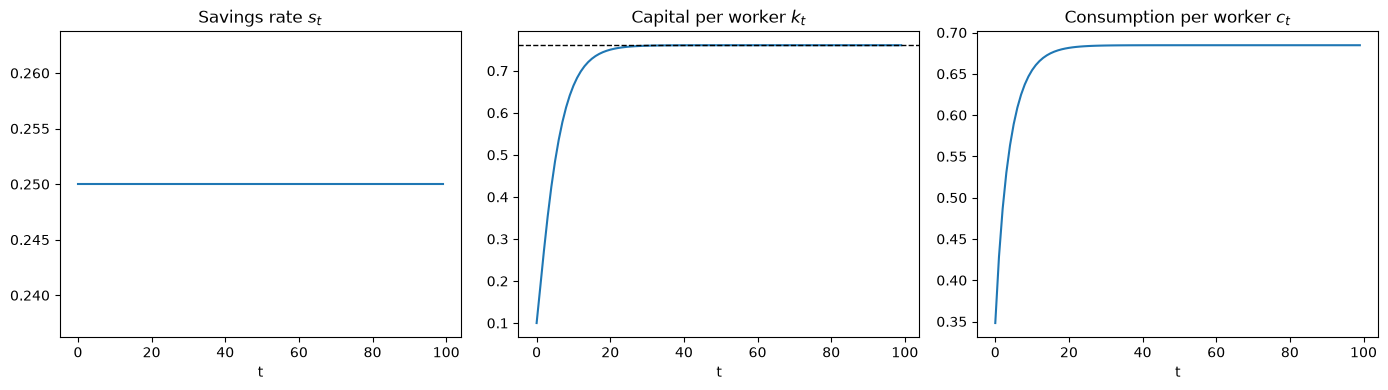

In [4]:
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(t, sim.s)
axes[0].set_title('Savings rate $s_t$')

axes[1].plot(t, sim.k)
axes[1].axhline(k_star, color='black', ls='--', lw=1)  # visual check of convergence
axes[1].set_title('Capital per worker $k_t$')

axes[2].plot(t, sim.c)
axes[2].set_title('Consumption per worker $c_t$')

for ax in axes: ax.set_xlabel('t')
fig.tight_layout()
plt.show()

We see that the savings rate ($s_t$) is constant as we defined it to be. We also see, that the two other variables capital per worker ($k_t$) and consumption per worker ($c_t$) converge towards their steady state values (which we have drawn with dashed lines).

### 2.1.3
Next we try uot two different asserts which can by verified 'by hand'.

In [5]:
# 1. starting exactly at the steady state, it must stay there
sim_star = model.simulate(par.s_bar, k0=k_star)
assert np.allclose(sim_star.k, k_star), 'capital should stay at the steady state'

# 2. with s=0, capital decays geometrically: k_t = (1-delta)**t * k0 and collapses to 0
sim_zero = model.simulate(0.0)
k_formula = (1-par.delta)**t * par.k0
assert np.allclose(sim_zero.k, k_formula), 'capital should decay as (1-delta)**t * k0'

print('both checks passed')

both checks passed


Since there are no error messages and the print at the end actually works, we conclude that the simulator actually calculates the correct values and converges toward the steady state value. That is - in the first test, capital stays at the steady state and in the second test capital decays quickly towards $0$. (We use the 'allclose' statement for the comparison).

## 2.2 Question 2

### 2.2.1 
Now we implement the new savings rule. We do this by updating the 's_path(self,s0,phi)', in the SolowModel.py-module. This can be verified by the examinator at the bottom of the Python file. 


We also make sure that we can recall the baseline values and the results which depending on the combos stated in the assignment.

In [6]:
combos = [(0.30, 0.50), (0.40, 0.80), (0.10, 0.50), (0.60, 0.60)]

paths = {}

baseline = model.simulate(par.s_bar)
paths['baseline'] = dict(s=baseline.s.copy(), k=baseline.k.copy(), c=baseline.c.copy())

for s0, phi in combos:
    label = f's0={s0}, phi={phi}'
    s_t = model.s_path(s0, phi)
    result = model.simulate(s_t)
    paths[label] = dict(s=result.s.copy(), k=result.k.copy(), c=result.c.copy())

### 2.2.2 
We simulate the model and plot the variables $s_t$, $k_t$ and $c_t$ or different combinations of intial savings $s_0$ and for 'willingness to save' $\phi$ as demanded. We do this in the same panel as in Question 1.

We should have that $ \phi^t \rightarrow 0$ as $t\rightarrow \infty$, because $\phi \in [0,1)$ i.e. is smaller than one. Therefore we should also have that $s_t \rightarrow \bar{s}$ (which is also stated in the assignment).

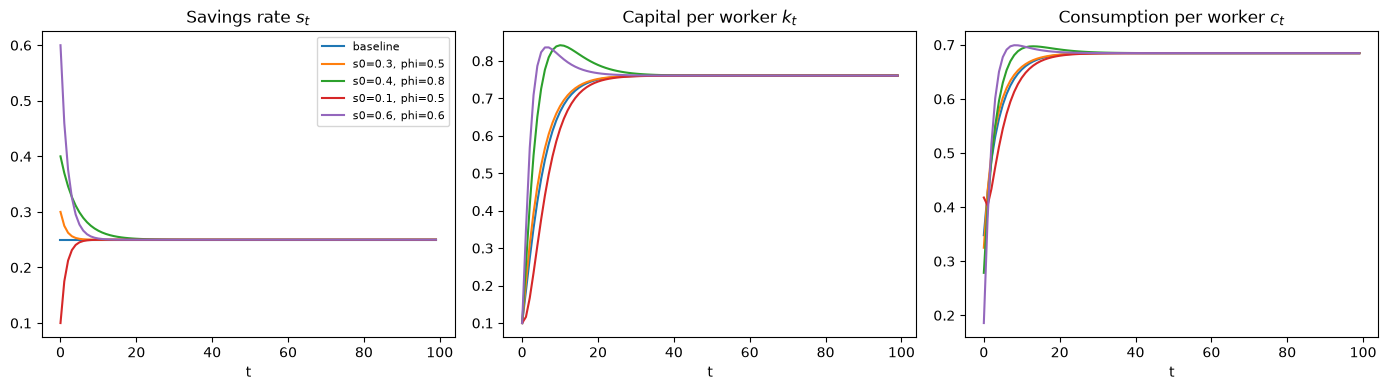

In [7]:
t = np.arange(par.T)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for label, p in paths.items():
    axes[0].plot(t, p['s'], label=label)
    axes[1].plot(t, p['k'], label=label)
    axes[2].plot(t, p['c'], label=label)

axes[0].set_title('Savings rate $s_t$')
axes[1].set_title('Capital per worker $k_t$')
axes[2].set_title('Consumption per worker $c_t$')
for ax in axes: ax.set_xlabel('t')
axes[0].legend(fontsize=8)

fig.tight_layout()
plt.show()

We see that as expected, the savings rate converges towards a constant level. This is also true for capial per worker and consumption per worker.

### 2.2.3
We now report the value of capital per worker in the last period $T-1$ for each combination of $s_0$ and $\phi$. We expect them to be the same, as they should converge towards the same values.

In [8]:
for label, p in paths.items():
    print(f'{label:22s} k[T-1] = {p["k"][-1]:.6f}')

baseline               k[T-1] = 0.760726
s0=0.3, phi=0.5        k[T-1] = 0.760726
s0=0.4, phi=0.8        k[T-1] = 0.760726
s0=0.1, phi=0.5        k[T-1] = 0.760726
s0=0.6, phi=0.6        k[T-1] = 0.760726


We see that they have converged to the same values as expected.

### 2.2.4

We see that $s_0$ determines the level of the savings rate. The purple case where $s_0 = 0.6$ gives a high start value of saving, whereas the red case ($s_0 =0.1$) gives the opposite. A higher initial savings rate gives a higher initial level of capital pr. worker and consumption pr. worker, which can be seen in the second plot, where the green and purple path surpasses the rest of the cases. The orange and red cases has the same convergence parameters ($\phi = \tfrac12$) but the orange converges to the baseline level much faster, because it starts closer to the final level of $\bar{s} = 0.25$

Comparatively the level of $\phi$ determines the speed of convergence. A higher value of $\phi$ gives a slower convergence, as seen in $(6)$ in the assignment. The reason is that the process of $\phi^t \rightarrow 0$ will be slower for greater values of $\phi$. 

The reason why the level of capital pr. worker is higher for the green path (with $s_0 = 0.4$ and $\phi = 0.8$) is that the two effects work together. Even though the inital savings rate for purple is much higher, the high savings rate perdue for longer for the green path. This gives a savings rate which is as high (or slightly higher) than the one of the purple path.

## 2.3 Question 3

### 2.3.1
Now we implement the wealth formula $W$. We do this by updating the 'stubs' 'welfare(self,c)' and 'evaluate(self,s0,phi)', in the SolowModel.py-module. This can be verified by the examinator at the bottom of the Python file. 
